In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

100%|██████████| 170M/170M [00:04<00:00, 42.3MB/s]


In [4]:
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 512, 4, 1, 0),
            nn.BatchNorm2d(512),
            nn.ReLU(),

            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

In [5]:
latent_dim = 100

generator = Generator(latent_dim).to(device)

# Freeze weights (lab requirement)
for param in generator.parameters():
    param.requires_grad = False

In [6]:
def generate_images(n_images):
    noise = torch.randn(n_images, latent_dim, 1, 1).to(device)
    fake_images = generator(noise).detach().cpu()

    return fake_images

In [7]:
def show_images(images):
    grid = torchvision.utils.make_grid(images, nrow=5, normalize=True)
    plt.figure(figsize=(8,8))
    plt.imshow(np.transpose(grid, (1,2,0)))
    plt.axis("off")
    plt.show()

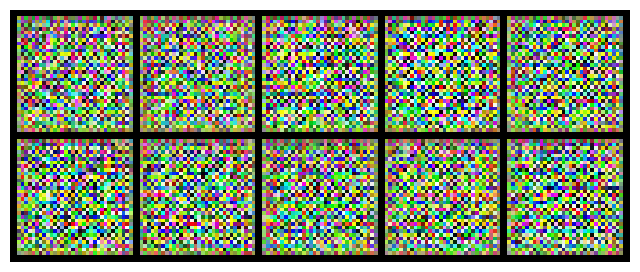

In [8]:
images = generate_images(10)
show_images(images)

In [9]:
def interpolate(z1, z2, steps=10):
    interpolated = []

    for alpha in np.linspace(0, 1, steps):
        z = (1 - alpha) * z1 + alpha * z2
        interpolated.append(z)

    return torch.stack(interpolated)

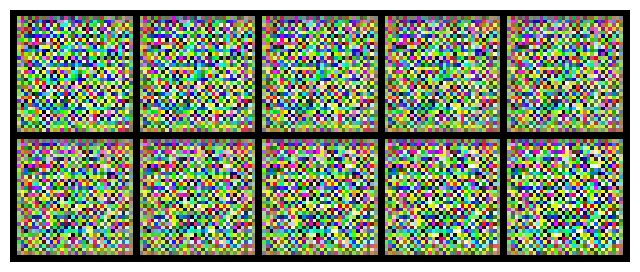

In [10]:
z1 = torch.randn(1, latent_dim, 1, 1).to(device)
z2 = torch.randn(1, latent_dim, 1, 1).to(device)

z_interp = interpolate(z1, z2, steps=10).squeeze(1)

images = generator(z_interp).detach().cpu()

show_images(images)